In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def configure_plots():
    """Configure seaborn and matplotlib settings"""
    sns.set(style="whitegrid", palette="muted")
    plt.rcParams['figure.figsize'] = [12, 6]
    plt.rcParams['font.size'] = 10

def plot_wavelength_ratios(feature_df):
    """
    Plot 850nm/730nm ratio features
    Note: This requires a 'bladder_state' column (you'll need to add this)
    """
    # Check if we have the required columns
    ratio_cols = [col for col in feature_df.columns if 'wavelength_ratio' in col and 'mean' in col]
    
    if not ratio_cols:
        print("No wavelength ratio columns found. Available columns:")
        print([col for col in feature_df.columns if 'ratio' in col])
        return
    
    # If you don't have bladder_state, we can just plot distributions
    if 'bladder_state' not in feature_df.columns:
        print("Note: 'bladder_state' column not found. Plotting distributions instead.")
        
        # Melt the dataframe for easier plotting
        ratio_data = feature_df[ratio_cols].melt(var_name='Ratio_Type', value_name='Ratio_Value')
        
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Ratio_Type', y='Ratio_Value', data=ratio_data)
        plt.title("850nm/730nm Wavelength Ratios")
        plt.xticks(rotation=45)
        plt.ylabel("Optical Density Ratio")
        plt.show()
        return
    
    # If we have bladder_state but no position, plot without hue
    if 'position' not in feature_df.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='bladder_state', y='wavelength_ratio_outer_mean', data=feature_df)
        plt.title("850nm/730nm Ratio by Bladder State")
        plt.ylabel("Optical Density Ratio")
        plt.show()
    else:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='bladder_state', y='wavelength_ratio_outer_mean', 
                    hue='position', data=feature_df)
        plt.title("850nm/730nm Ratio by Bladder State and Sensor Position")
        plt.ylabel("Optical Density Ratio")
        plt.legend(title="Sensor Position")
        plt.show()

def plot_spatial_asymmetry(feature_df):
    """
    Plot left-right asymmetry features
    """
    # Find asymmetry columns
    asymmetry_cols = [col for col in feature_df.columns if 'left_right' in col and 'diff' in col]
    
    if len(asymmetry_cols) < 2:
        print(f"Found only {len(asymmetry_cols)} asymmetry columns. Need at least 2 for scatter plot.")
        print("Available asymmetry columns:", asymmetry_cols)
        
        # If only one asymmetry column, plot distribution instead
        if asymmetry_cols:
            plt.figure(figsize=(10, 6))
            sns.histplot(data=feature_df, x=asymmetry_cols[0], kde=True)
            plt.title(f"Distribution of {asymmetry_cols[0]}")
            plt.show()
        return
    
    # Find the 730nm and 850nm asymmetry columns
    asym_730 = [col for col in asymmetry_cols if '730' in col]
    asym_850 = [col for col in asymmetry_cols if '850' in col]
    
    if not asym_730 or not asym_850:
        print("Could not find both 730nm and 850nm asymmetry columns")
        return
    
    # Check if we have grouping columns
    if 'bladder_state' in feature_df.columns and 'position' in feature_df.columns:
        g = sns.FacetGrid(feature_df, col="position", hue="bladder_state", height=4)
        g.map(sns.scatterplot, asym_850[0], asym_730[0], alpha=0.7)
        g.add_legend()
        g.set_axis_labels("850nm Asymmetry", "730nm Asymmetry")
        plt.suptitle("Left-Right Optical Asymmetry", y=1.05)
        plt.show()
    elif 'bladder_state' in feature_df.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=asym_850[0], y=asym_730[0], 
                       hue='bladder_state', data=feature_df, alpha=0.7)
        plt.xlabel("850nm Asymmetry")
        plt.ylabel("730nm Asymmetry")
        plt.title("Left-Right Optical Asymmetry by Bladder State")
        plt.show()
    else:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=asym_850[0], y=asym_730[0], data=feature_df, alpha=0.7)
        plt.xlabel("850nm Asymmetry")
        plt.ylabel("730nm Asymmetry")
        plt.title("Left-Right Optical Asymmetry")
        plt.show()

def plot_feature_correlation(feature_df, top_n=None):
    """
    Plot correlation matrix of features
    top_n: If provided, only show top N features by variance
    """
    # Select only numeric columns (exclude metadata)
    exclude_cols = ['window_id', 'prediction_time_sec']
    numeric_cols = [col for col in feature_df.columns 
                   if col not in exclude_cols and feature_df[col].dtype in ['float64', 'int64']]
    
    if not numeric_cols:
        print("No numeric columns found for correlation")
        return
    
    # Optionally select top N features by variance
    if top_n and top_n < len(numeric_cols):
        variances = feature_df[numeric_cols].var()
        top_features = variances.nlargest(top_n).index.tolist()
        numeric_cols = top_features
        print(f"Showing top {top_n} features by variance")
    
    # Calculate correlation
    corr = feature_df[numeric_cols].corr()
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Adjust figure size based on number of features
    fig_size = min(20, max(8, len(numeric_cols) * 0.5))
    plt.figure(figsize=(fig_size, fig_size))
    
    # Plot heatmap
    sns.heatmap(corr, mask=mask, cmap="vlag", center=0, 
                annot=len(numeric_cols) < 20,  # Only show annotations if fewer than 20 features
                fmt=".2f", linewidths=.5, 
                square=True, cbar_kws={"shrink": 0.8})
    
    plt.title(f"Feature Correlation Matrix ({len(numeric_cols)} features)")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Print highly correlated feature pairs
    print("\nHighly correlated feature pairs (|corr| > 0.8):")
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > 0.8:
                print(f"  {corr.columns[i]} ↔ {corr.columns[j]}: {corr.iloc[i, j]:.3f}")

def plot_feature_importance(feature_df, target_col='bladder_state'):
    """
    Plot feature importance using simple ANOVA F-test
    Requires a target column (e.g., bladder_state)
    """
    from scipy.stats import f_oneway
    
    if target_col not in feature_df.columns:
        print(f"Target column '{target_col}' not found. Available columns:")
        print([col for col in feature_df.columns if 'state' in col or 'label' in col])
        return
    
    # Get unique groups
    groups = feature_df[target_col].unique()
    if len(groups) < 2:
        print(f"Target column '{target_col}' has only one unique value: {groups}")
        return
    
    # Select feature columns
    exclude_cols = ['window_id', 'prediction_time_sec', target_col]
    feature_cols = [col for col in feature_df.columns 
                   if col not in exclude_cols and feature_df[col].dtype in ['float64', 'int64']]
    
    # Calculate F-statistic for each feature
    f_stats = []
    p_values = []
    
    for col in feature_cols:
        # Group data by target
        group_data = [feature_df[feature_df[target_col] == g][col].dropna().values 
                     for g in groups]
        
        # Remove empty groups
        group_data = [g for g in group_data if len(g) > 0]
        
        if len(group_data) >= 2:
            f_stat, p_val = f_oneway(*group_data)
            f_stats.append(f_stat)
            p_values.append(p_val)
        else:
            f_stats.append(0)
            p_values.append(1)
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'f_statistic': f_stats,
        'p_value': p_values
    }).sort_values('f_statistic', ascending=False)
    
    # Plot top 20 features
    top_n = min(20, len(importance_df))
    plt.figure(figsize=(10, 8))
    sns.barplot(x='f_statistic', y='feature', data=importance_df.head(top_n))
    plt.title(f"Top {top_n} Features by ANOVA F-statistic\n(Target: {target_col})")
    plt.xlabel("F-statistic")
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print(f"\nTop 10 features for predicting {target_col}:")
    for i, row in importance_df.head(10).iterrows():
        sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
        print(f"  {row['feature']}: F={row['f_statistic']:.2f} (p={row['p_value']:.4f}) {sig}")

def plot_time_series_features(feature_df, feature_col, window_col='prediction_time_sec'):
    """
    Plot how a feature changes over time (useful for tracking bladder filling)
    """
    if feature_col not in feature_df.columns:
        print(f"Feature '{feature_col}' not found")
        return
    
    if window_col not in feature_df.columns:
        print(f"Time column '{window_col}' not found")
        return
    
    plt.figure(figsize=(12, 5))
    
    # Sort by time
    plot_df = feature_df.sort_values(window_col)
    
    plt.plot(plot_df[window_col], plot_df[feature_col], 'b-', alpha=0.7, linewidth=1)
    plt.xlabel("Time (seconds)")
    plt.ylabel(feature_col)
    plt.title(f"Feature Evolution Over Time: {feature_col}")
    plt.grid(True, alpha=0.3)
    
    # Add smoothing line
    from scipy.ndimage import gaussian_filter1d
    if len(plot_df) > 10:
        smoothed = gaussian_filter1d(plot_df[feature_col].values, sigma=2)
        plt.plot(plot_df[window_col], smoothed, 'r-', linewidth=2, label='Smoothed')
        plt.legend()
    
    plt.tight_layout()
    plt.show()



In [2]:
def is_high_quality(features, snr_threshold=3, artifact_threshold=0.1):
    """
    Check if a window has high quality signals
    Note: Updated to work with your feature DataFrame
    """
    # Check if we have quality metrics (you may need to uncomment signal_quality_metric in feature extraction)
    
    # If you have HbO/HbR features, use their stability as quality proxy
    if 'left_outer_HbO_std' in features:
        hbo_std = features['left_outer_HbO_std']
        if hbo_std > 0.5:  # Too much variation = likely motion artifact
            return False
    
    # Check wavelength ratio reasonability
    if 'wavelength_ratio_outer_mean' in features:
        ratio = features['wavelength_ratio_outer_mean']
        if ratio < 0.5 or ratio > 2.0:  # Physiological range
            return False
    
    return True





In [3]:
# Main function to run all plots
def analyze_features(feature_csv_path, target_col=None):
    """
    Load feature CSV and generate all plots
    """
    # Load data
    feature_df = pd.read_csv(feature_csv_path)
    print(f"Loaded {len(feature_df)} windows with {len(feature_df.columns)} columns")
    
    # Configure plots
    configure_plots()
    
    # Generate plots
    print("\n" + "="*60)
    print("1. Wavelength Ratio Analysis")
    print("="*60)
    plot_wavelength_ratios(feature_df)
    
    print("\n" + "="*60)
    print("2. Spatial Asymmetry Analysis")
    print("="*60)
    plot_spatial_asymmetry(feature_df)
    
    print("\n" + "="*60)
    print("3. Feature Correlation Matrix")
    print("="*60)
    plot_feature_correlation(feature_df, top_n=30)
    
    # If you have a target column (bladder state), do feature importance
    if target_col and target_col in feature_df.columns:
        print("\n" + "="*60)
        print("4. Feature Importance Analysis")
        print("="*60)
        plot_feature_importance(feature_df, target_col)
    
    # Plot top features over time
    print("\n" + "="*60)
    print("5. Feature Time Series (Top 3 features by variance)")
    print("="*60)
    
    # Find most variable features
    numeric_cols = [col for col in feature_df.columns 
                   if col not in ['window_id', 'prediction_time_sec'] 
                   and feature_df[col].dtype in ['float64', 'int64']]
    
    if numeric_cols:
        variances = feature_df[numeric_cols].var()
        top_features = variances.nlargest(3).index.tolist()
        
        for feature in top_features:
            print(f"\nPlotting: {feature}")
            plot_time_series_features(feature_df, feature)
    
    return feature_df

Loaded 147 windows with 129 columns

1. Wavelength Ratio Analysis
Note: 'bladder_state' column not found. Plotting distributions instead.


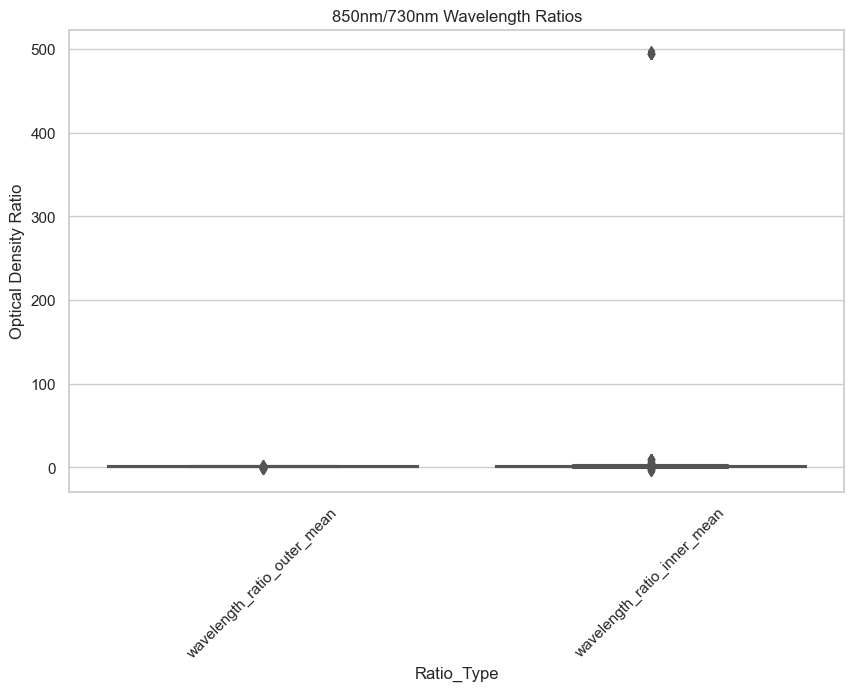


2. Spatial Asymmetry Analysis


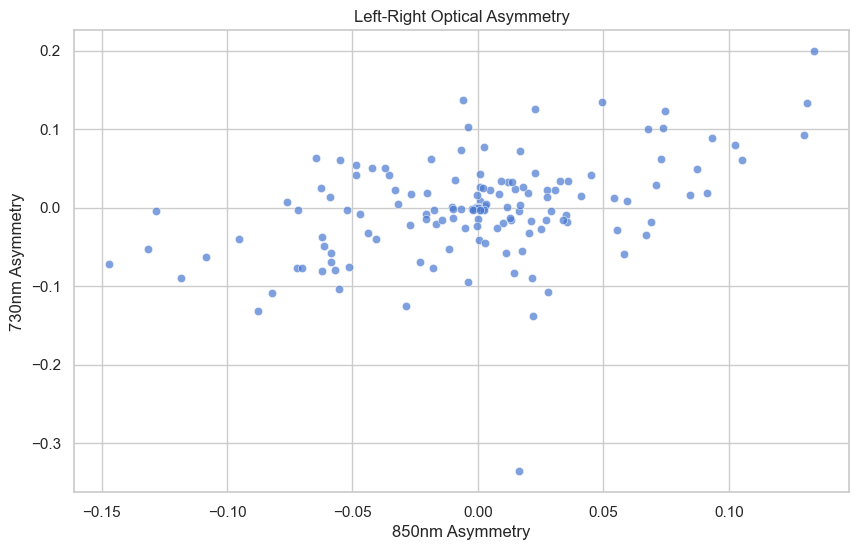


3. Feature Correlation Matrix
Showing top 30 features by variance


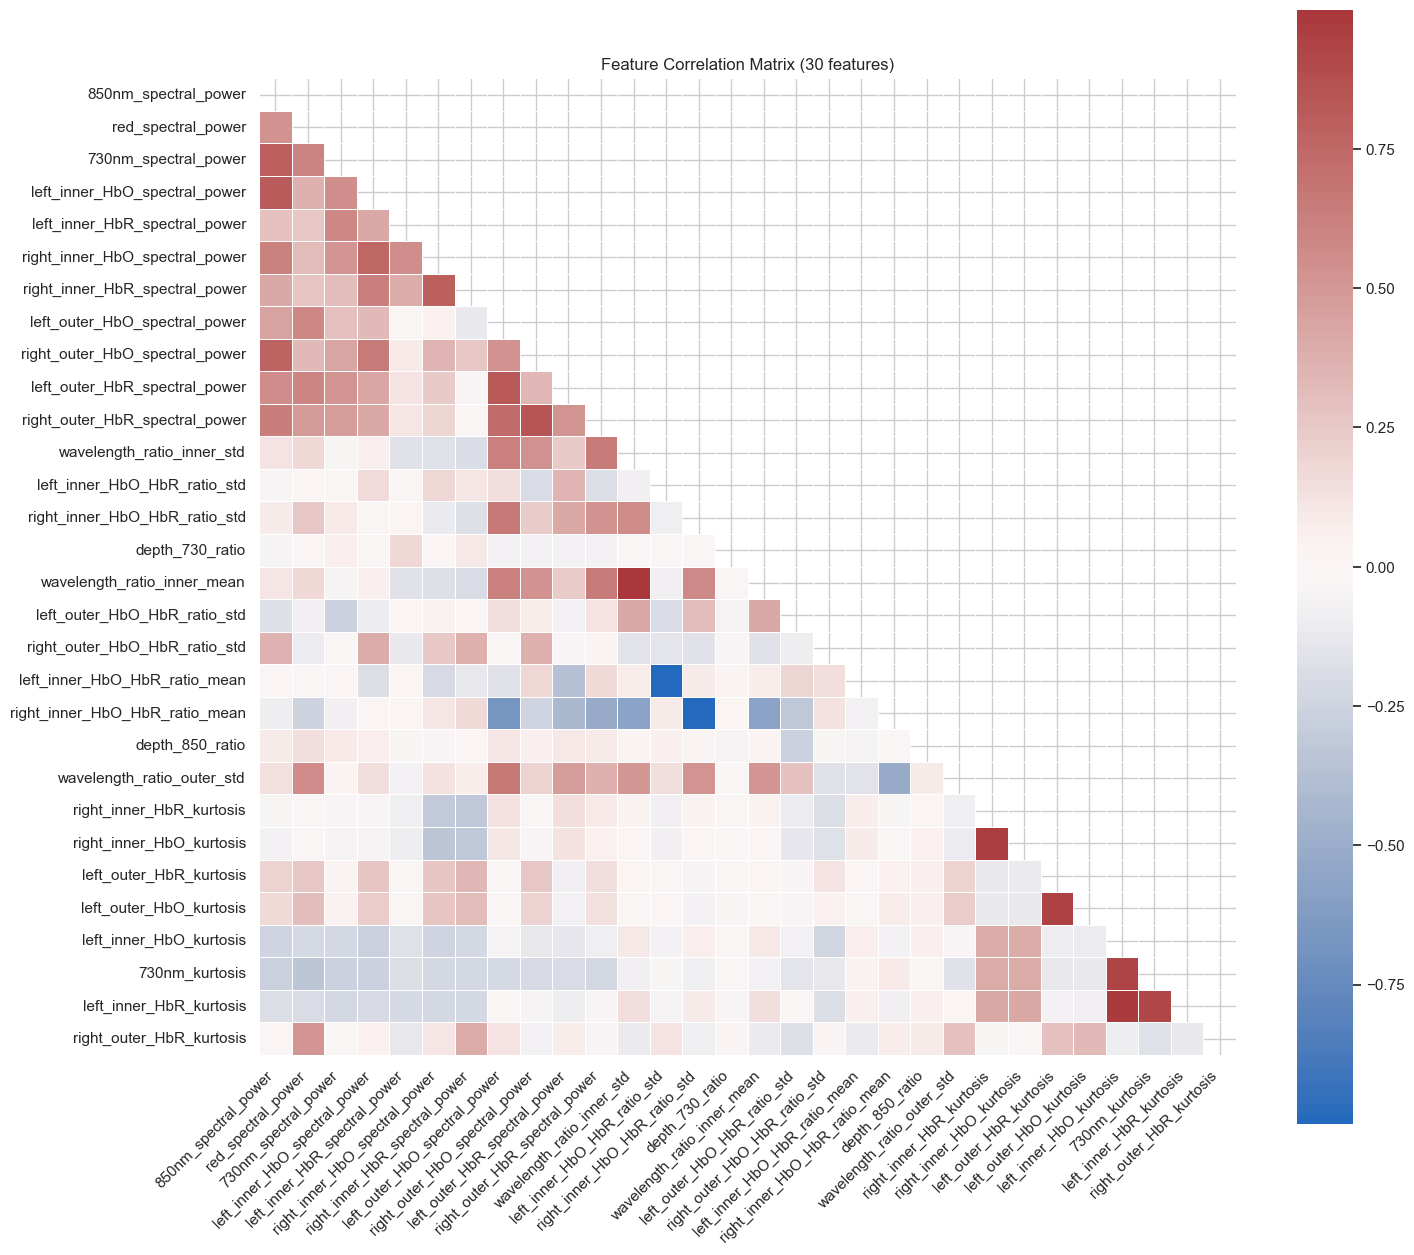


Highly correlated feature pairs (|corr| > 0.8):
  850nm_spectral_power ↔ 730nm_spectral_power: 0.804
  850nm_spectral_power ↔ left_inner_HbO_spectral_power: 0.813
  left_outer_HbO_spectral_power ↔ left_outer_HbR_spectral_power: 0.821
  right_outer_HbO_spectral_power ↔ right_outer_HbR_spectral_power: 0.851
  wavelength_ratio_inner_std ↔ wavelength_ratio_inner_mean: 1.000
  left_inner_HbO_HbR_ratio_std ↔ left_inner_HbO_HbR_ratio_mean: -0.999
  right_inner_HbO_HbR_ratio_std ↔ right_inner_HbO_HbR_ratio_mean: -0.997
  right_inner_HbR_kurtosis ↔ right_inner_HbO_kurtosis: 0.976
  left_outer_HbR_kurtosis ↔ left_outer_HbO_kurtosis: 0.951
  left_inner_HbO_kurtosis ↔ 730nm_kurtosis: 0.933
  left_inner_HbO_kurtosis ↔ left_inner_HbR_kurtosis: 0.978
  730nm_kurtosis ↔ left_inner_HbR_kurtosis: 0.928

5. Feature Time Series (Top 3 features by variance)

Plotting: 850nm_spectral_power


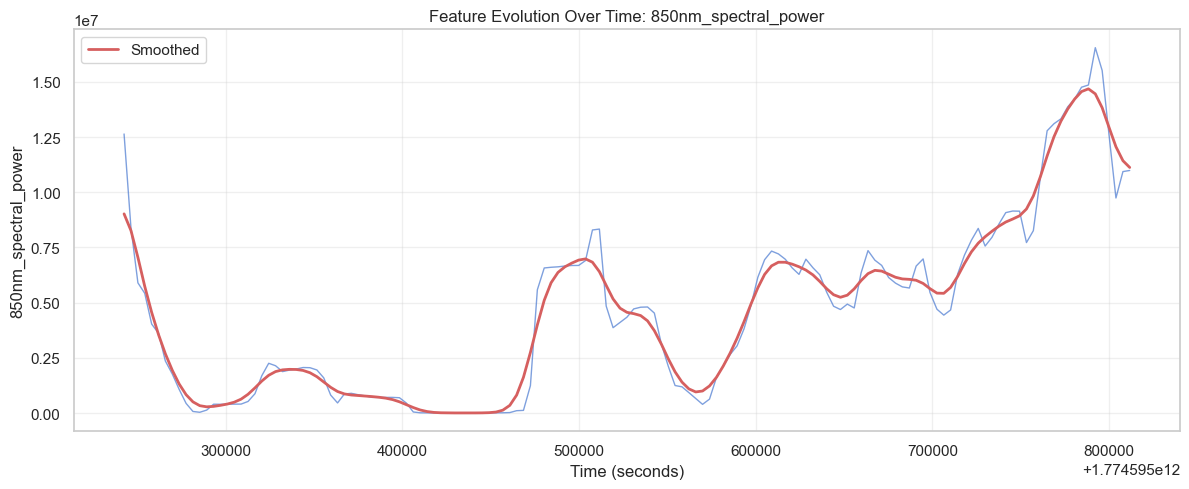


Plotting: red_spectral_power


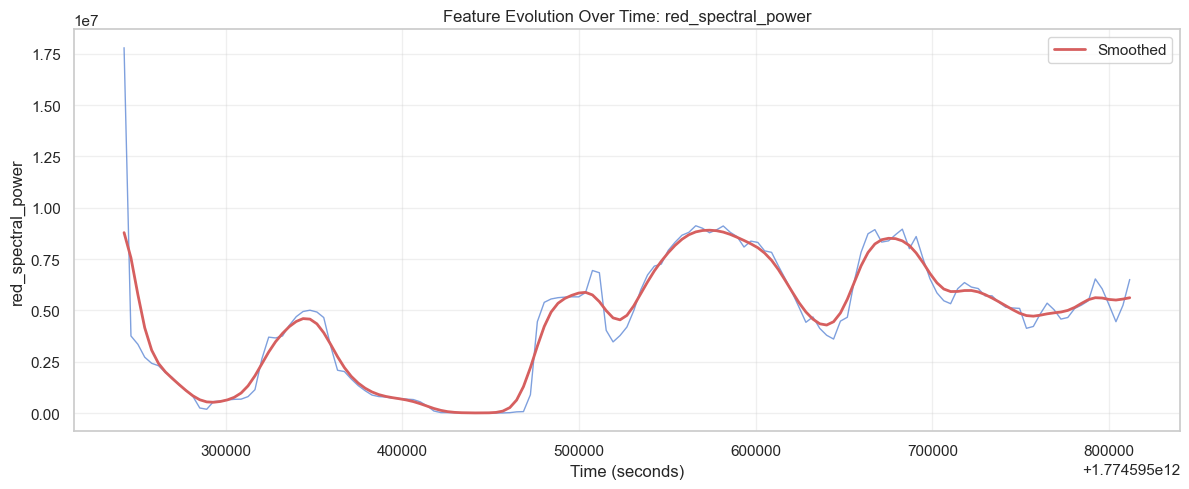


Plotting: 730nm_spectral_power


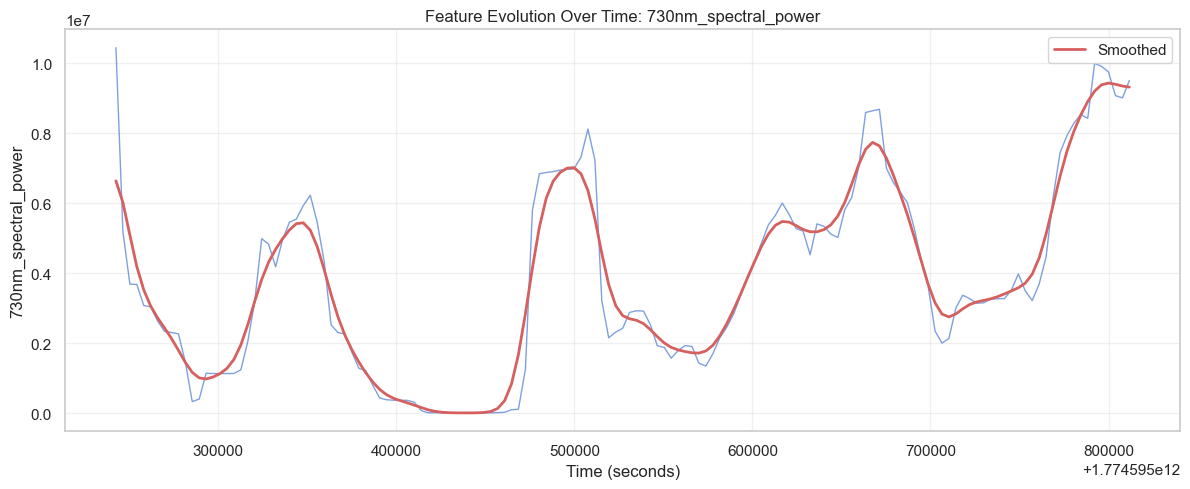

In [7]:
feature_df = analyze_features("optics_data_2026-03-27_15-06-34_part1.cleaned_windows_features.csv",
                              target_col=None)

Note: 'bladder_state' column not found. Plotting distributions instead.


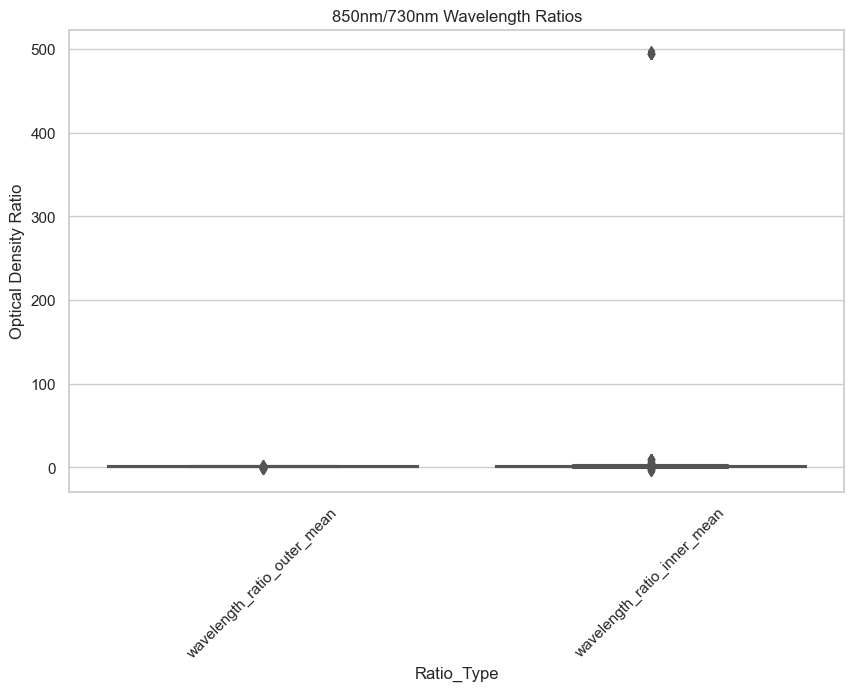

In [8]:
plot_wavelength_ratios(feature_df)


Showing top 20 features by variance


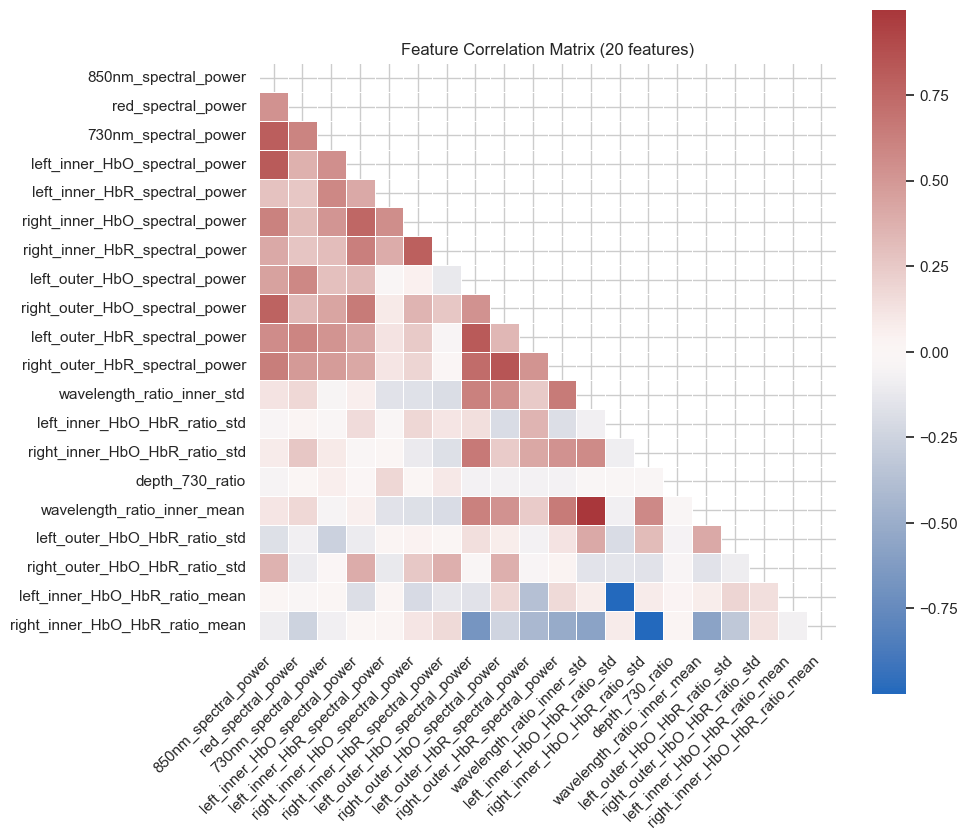


Highly correlated feature pairs (|corr| > 0.8):
  850nm_spectral_power ↔ 730nm_spectral_power: 0.804
  850nm_spectral_power ↔ left_inner_HbO_spectral_power: 0.813
  left_outer_HbO_spectral_power ↔ left_outer_HbR_spectral_power: 0.821
  right_outer_HbO_spectral_power ↔ right_outer_HbR_spectral_power: 0.851
  wavelength_ratio_inner_std ↔ wavelength_ratio_inner_mean: 1.000
  left_inner_HbO_HbR_ratio_std ↔ left_inner_HbO_HbR_ratio_mean: -0.999
  right_inner_HbO_HbR_ratio_std ↔ right_inner_HbO_HbR_ratio_mean: -0.997


In [9]:
plot_feature_correlation(feature_df, top_n=20)

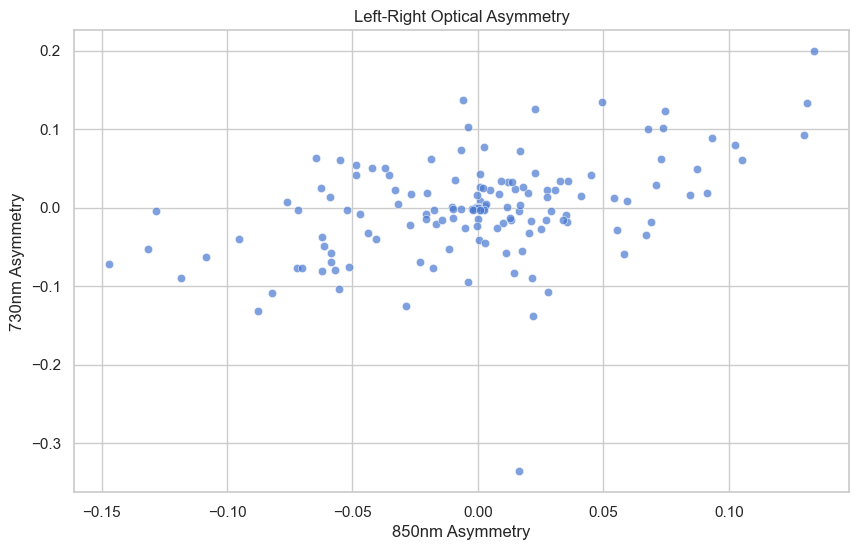

In [10]:
plot_spatial_asymmetry(feature_df)

In [12]:
#plot_feature_importance(feature_df, target_col='bladder_state')